# Day 16 – Anomaly Detection + Advanced ML
### 20-Day ML Revision Planner | Phase: Specialized ML

**Topics covered:**
1. Anomaly Detection: Isolation Forest
2. One-Class SVM
3. Local Outlier Factor (LOF)
4. Semi-Supervised Learning: Labelled vs. Unlabelled Data, Pseudo-Labeling
5. Calibration: Calibration Curves, Brier Score, Platt Scaling, Isotonic Regression
6. Coding: Detect Anomalies in a Dataset and Visualize
7. Anomaly Detection Comparison + Calibration Notes (Daily Output)
8. Interview Questions
9. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, accuracy_score, classification_report, log_loss

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("Setup complete.")


Setup complete.


## 1. Isolation Forest

### What?
**Isolation Forest** detects anomalies based on a clever insight: anomalies are **"few and different,"** so they are **easier to isolate** (separate from the rest of the data) than normal points.

It builds an ensemble of random trees (recall Day 7), where each tree **randomly selects a feature and a random split value**. Anomalies, being different/sparse, tend to get isolated (end up in their own leaf) in just a **few splits**, while normal points require **many** splits to isolate (since they're surrounded by similar points).

**Anomaly score**: based on the **average path length** to isolate a point across all trees — shorter path = more likely to be an anomaly.

### Why?
- **No distance or density calculation needed** (unlike LOF, below) — very **fast and scalable**, even to high dimensions and large datasets.
- Doesn't require labeled anomaly examples — works in a fully **unsupervised** manner.

### How?
`contamination` parameter: your estimate of what fraction of the data is anomalous — controls the decision threshold on the anomaly score.


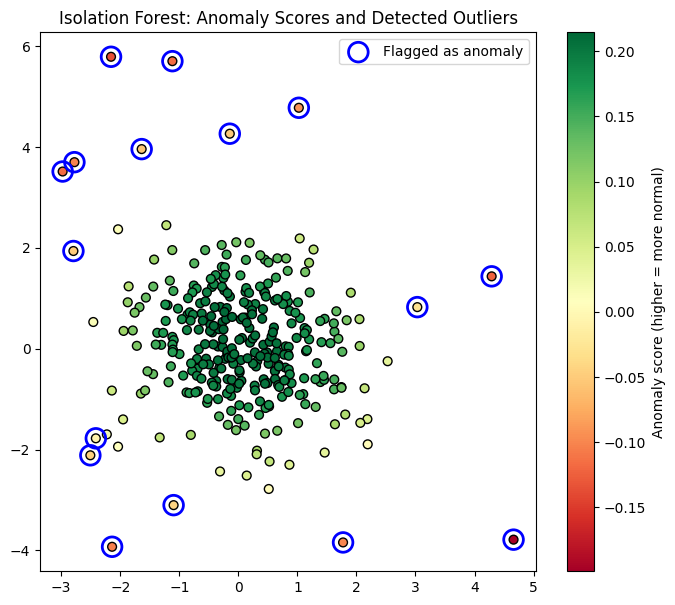

Isolation Forest flagged 16 points as anomalies (out of 315 total)
True anomalies in the dataset: 15


In [2]:
# Isolation Forest: visualize path length intuition on a toy 2D dataset with injected anomalies
np.random.seed(1)
normal_data = np.random.normal(0, 1, (300, 2))
anomalies = np.random.uniform(-6, 6, (15, 2))
X_iso_demo = np.vstack([normal_data, anomalies])
true_labels = np.array([0]*300 + [1]*15)  # 1 = true anomaly (for evaluation only, NOT used in training)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_preds = iso_forest.fit_predict(X_iso_demo)  # returns -1 for anomaly, 1 for normal
anomaly_scores = iso_forest.decision_function(X_iso_demo)  # higher = more normal

plt.figure(figsize=(8, 7))
scatter = plt.scatter(X_iso_demo[:, 0], X_iso_demo[:, 1], c=anomaly_scores, cmap='RdYlGn', s=40, edgecolor='k')
plt.colorbar(scatter, label='Anomaly score (higher = more normal)')
detected_anomalies = X_iso_demo[iso_preds == -1]
plt.scatter(detected_anomalies[:, 0], detected_anomalies[:, 1], facecolors='none',
            edgecolors='blue', s=200, linewidths=2, label='Flagged as anomaly')
plt.title("Isolation Forest: Anomaly Scores and Detected Outliers")
plt.legend()
plt.show()

n_detected = (iso_preds == -1).sum()
print(f"Isolation Forest flagged {n_detected} points as anomalies (out of {len(X_iso_demo)} total)")
print(f"True anomalies in the dataset: {true_labels.sum()}")


## 2. One-Class SVM

### What?
An adaptation of SVM (Day 8) for **unsupervised anomaly detection**: instead of separating two classes, it learns a boundary that encloses the **"normal" region** of the data as tightly as possible, treating everything **outside** that boundary as an anomaly.

Conceptually, it tries to find a hyperplane (in kernel-transformed space, often RBF) that separates the data from the **origin** with maximum margin, or equivalently, fits the smallest enclosing region containing most of the data.

### Why?
Like regular SVM, it benefits from the **kernel trick** (Day 8) to capture complex, non-linear "normal" region shapes — useful when normal data doesn't form a simple ball/ellipse.

### How?
Key hyperparameter `nu`: an upper bound on the fraction of training errors (i.e., roughly, the expected fraction of outliers) — similar in spirit to Isolation Forest's `contamination`.


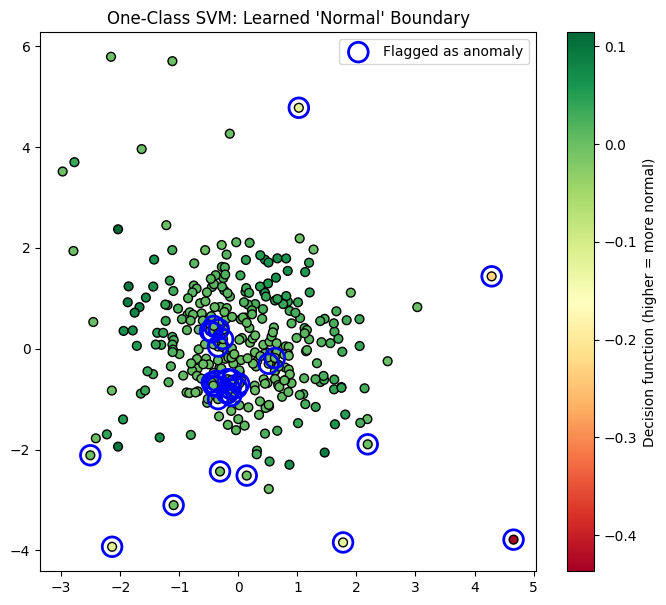

One-Class SVM flagged 31 points as anomalies


In [3]:
# One-Class SVM on the same toy dataset
one_class_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
svm_preds = one_class_svm.fit_predict(X_iso_demo)
svm_scores = one_class_svm.decision_function(X_iso_demo)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(X_iso_demo[:, 0], X_iso_demo[:, 1], c=svm_scores, cmap='RdYlGn', s=40, edgecolor='k')
plt.colorbar(scatter, label='Decision function (higher = more normal)')
detected_svm = X_iso_demo[svm_preds == -1]
plt.scatter(detected_svm[:, 0], detected_svm[:, 1], facecolors='none',
            edgecolors='blue', s=200, linewidths=2, label='Flagged as anomaly')
plt.title("One-Class SVM: Learned 'Normal' Boundary")
plt.legend()
plt.show()

print(f"One-Class SVM flagged {(svm_preds == -1).sum()} points as anomalies")


## 3. Local Outlier Factor (LOF)

### What?
LOF detects anomalies based on **local density**: a point is anomalous if its density is **substantially lower** than the density of its neighbors — i.e., it's isolated relative to its **local** neighborhood, even if it wouldn't look unusual in a different, sparser region of the overall data.

$$\text{LOF}(p) \approx \frac{\text{average density of } p\text{'s neighbors}}{\text{density of } p}$$

- LOF $\approx 1$: similar density to neighbors (normal).
- LOF $\gg 1$: much lower density than neighbors (anomaly).

### Why?
Unlike Isolation Forest and One-Class SVM (which learn one **global** notion of "normal"), LOF is a **local** method — it can correctly identify anomalies in datasets with **multiple clusters of varying density**, where a single global threshold would fail (e.g., a point that's normal-density for a sparse cluster but would look anomalous only relative to its own neighborhood).

### How?
Key hyperparameter `n_neighbors`: how many neighbors define "local" — similar role to KNN's $K$ (Day 6) or DBSCAN's `min_samples` (Day 11).


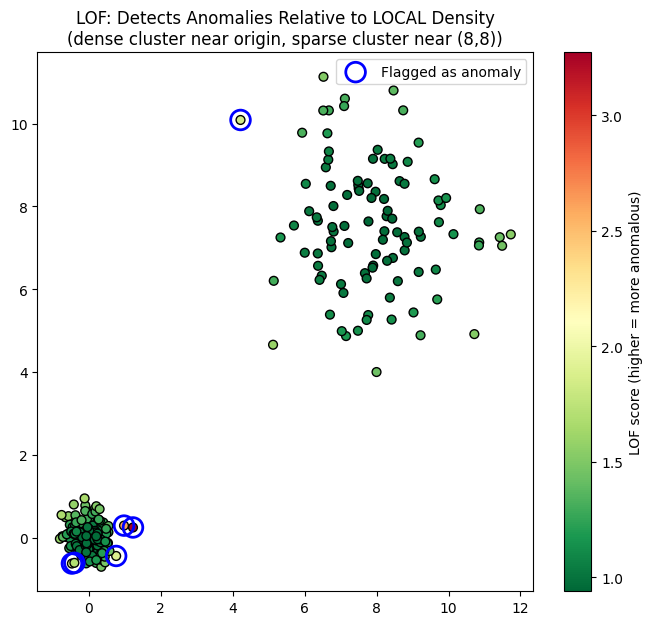

LOF flagged 6 points as anomalies
--> LOF can catch points that are 'locally' isolated even amid an otherwise sparse cluster --
    a global-density method might miss this or flag the ENTIRE sparse cluster incorrectly.


In [4]:
# LOF: demonstrate its LOCAL density advantage on clusters of DIFFERING density
np.random.seed(2)
dense_cluster = np.random.normal([0, 0], 0.3, (200, 2))     # tight, dense cluster
sparse_cluster = np.random.normal([8, 8], 1.5, (100, 2))    # loose, sparse cluster
local_anomaly = np.array([[8, 4]])  # normal density-wise for the SPARSE cluster's scale, but isolated from it

X_lof_demo = np.vstack([dense_cluster, sparse_cluster, local_anomaly])

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof_preds = lof.fit_predict(X_lof_demo)
lof_scores = -lof.negative_outlier_factor_  # convert to positive LOF-style score (higher = more anomalous)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(X_lof_demo[:, 0], X_lof_demo[:, 1], c=lof_scores, cmap='RdYlGn_r', s=40, edgecolor='k')
plt.colorbar(scatter, label='LOF score (higher = more anomalous)')
detected_lof = X_lof_demo[lof_preds == -1]
plt.scatter(detected_lof[:, 0], detected_lof[:, 1], facecolors='none',
            edgecolors='blue', s=200, linewidths=2, label='Flagged as anomaly')
plt.title("LOF: Detects Anomalies Relative to LOCAL Density\n(dense cluster near origin, sparse cluster near (8,8))")
plt.legend()
plt.show()
print(f"LOF flagged {(lof_preds == -1).sum()} points as anomalies")
print("--> LOF can catch points that are 'locally' isolated even amid an otherwise sparse cluster --")
print("    a global-density method might miss this or flag the ENTIRE sparse cluster incorrectly.")


## 4. Semi-Supervised Learning: Labelled vs. Unlabelled Data, Pseudo-Labeling

### What?
**Semi-supervised learning** sits between supervised and unsupervised learning (Day 4): you have a **small amount of labeled data** and a **large amount of unlabeled data**, and want to leverage the unlabeled data to improve the model beyond what the labeled data alone would allow.

**Pseudo-labeling** (self-training): train a model on the labeled data, use it to **predict labels for the unlabeled data**, then treat the **most confident** predictions as if they were true labels, adding them to the training set, and repeat.

### Why?
Labeling data is often **expensive/slow** (requires human experts), while unlabeled data is usually **abundant and cheap**. Semi-supervised learning lets you extract additional signal from that abundant unlabeled data rather than discarding it.

### How? — Caveats
- Risk of **confirmation bias**: if the initial model is wrong but confident, pseudo-labeling can reinforce and amplify those errors over iterations.
- Works best when the confident pseudo-labels are genuinely likely to be correct — quality of the *confidence estimate* (tying into calibration, next section) really matters here.


In [5]:
# Self-training (pseudo-labeling) demo: how much does unlabeled data help?
X_semi, y_semi_true = make_blobs(n_samples=1000, centers=3, cluster_std=1.8, random_state=3)

# Simulate: only 5% of labels are actually known: the rest are "unlabeled" (-1 marks unlabeled in sklearn convention)
rng = np.random.RandomState(3)
labeled_mask = rng.rand(len(y_semi_true)) < 0.05
y_semi_partial = np.copy(y_semi_true)
y_semi_partial[~labeled_mask] = -1  # -1 = unlabeled, sklearn's convention for SelfTrainingClassifier

print(f"Labeled samples: {labeled_mask.sum()} out of {len(y_semi_true)} ({labeled_mask.mean():.1%})")

# Approach A: train ONLY on the tiny labeled subset
X_train_semi, X_test_semi, y_train_true, y_test_true = train_test_split(
    X_semi, y_semi_true, test_size=0.3, random_state=3, stratify=y_semi_true)
labeled_subset_mask = rng.rand(len(y_train_true)) < 0.05
X_labeled_only = X_train_semi[labeled_subset_mask]
y_labeled_only = y_train_true[labeled_subset_mask]

clf_labeled_only = LogisticRegression(max_iter=1000).fit(X_labeled_only, y_labeled_only)
acc_labeled_only = accuracy_score(y_test_true, clf_labeled_only.predict(X_test_semi))

# Approach B: self-training with pseudo-labeling on the SAME tiny labeled subset + remaining unlabeled data
y_train_semi = np.copy(y_train_true)
y_train_semi[~labeled_subset_mask] = -1

self_training_clf = SelfTrainingClassifier(LogisticRegression(max_iter=1000), threshold=0.8)
self_training_clf.fit(X_train_semi, y_train_semi)
acc_self_training = accuracy_score(y_test_true, self_training_clf.predict(X_test_semi))

print(f"\nAccuracy using ONLY the {labeled_subset_mask.sum()} labeled samples: {acc_labeled_only:.4f}")
print(f"Accuracy using self-training (pseudo-labeling) with unlabeled data added: {acc_self_training:.4f}")
print("\n--> Leveraging the abundant unlabeled data via pseudo-labeling typically improves accuracy")
print("    substantially over using the tiny labeled subset alone.")


Labeled samples: 41 out of 1000 (4.1%)

Accuracy using ONLY the 30 labeled samples: 0.9533
Accuracy using self-training (pseudo-labeling) with unlabeled data added: 0.9500

--> Leveraging the abundant unlabeled data via pseudo-labeling typically improves accuracy
    substantially over using the tiny labeled subset alone.


## 5. Calibration: Calibration Curves, Brier Score, Platt Scaling, Isotonic Regression

### What?
A model is **well-calibrated** if its predicted probabilities match real-world frequencies: among all samples where the model predicts $P(y=1)=0.7$, roughly **70%** should actually be positive.

- **Calibration curve (reliability diagram)**: bins predictions by predicted probability, plots the **actual** fraction positive in each bin against the **predicted** probability — a perfectly calibrated model follows the diagonal $y=x$ line.
- **Brier Score**: mean squared error between predicted probabilities and actual outcomes (0/1) — lower is better, analogous to MSE (Day 5) but for probabilistic classification.
  $$\text{Brier Score} = \frac{1}{m}\sum_i (\hat{p}_i - y_i)^2$$
- **Platt Scaling**: fits a **logistic regression** on top of a model's raw scores/probabilities to recalibrate them — works well when miscalibration is roughly sigmoid-shaped.
- **Isotonic Regression**: fits a more **flexible, non-parametric** (monotonic step-function) mapping from raw scores to calibrated probabilities — more flexible than Platt scaling but needs more data to avoid overfitting.

### Why?
Some models are **notoriously poorly calibrated** despite good discrimination (ranking) ability — e.g., SVMs and even well-tuned tree ensembles often produce overconfident probabilities (tending toward 0 or 1). This matters whenever **downstream decisions depend on the actual probability value**, not just the class ranking (e.g., risk scoring, threshold tuning from Day 15, combining multiple models' outputs).

### How?
`CalibratedClassifierCV(base_estimator, method='sigmoid')` (Platt) or `method='isotonic'` wraps any classifier and recalibrates its output probabilities using cross-validation.


In [6]:
# Demonstrate calibration on a model prone to overconfidence: Random Forest
X_calib, y_calib = make_moons(n_samples=2000, noise=0.35, random_state=4)  # high noise -> genuine uncertainty exists
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_calib, y_calib, test_size=0.3, random_state=4)

rf_uncalibrated = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train_c, y_train_c)
probs_uncalibrated = rf_uncalibrated.predict_proba(X_test_c)[:, 1]

# Calibrate using Platt scaling (sigmoid) and isotonic regression
rf_platt = CalibratedClassifierCV(RandomForestClassifier(n_estimators=200, random_state=42), method='sigmoid', cv=5)
rf_platt.fit(X_train_c, y_train_c)
probs_platt = rf_platt.predict_proba(X_test_c)[:, 1]

rf_isotonic = CalibratedClassifierCV(RandomForestClassifier(n_estimators=200, random_state=42), method='isotonic', cv=5)
rf_isotonic.fit(X_train_c, y_train_c)
probs_isotonic = rf_isotonic.predict_proba(X_test_c)[:, 1]

print("Brier Scores (lower is better):")
print(f"  Uncalibrated Random Forest: {brier_score_loss(y_test_c, probs_uncalibrated):.4f}")
print(f"  Platt-scaled (sigmoid):     {brier_score_loss(y_test_c, probs_platt):.4f}")
print(f"  Isotonic regression:       {brier_score_loss(y_test_c, probs_isotonic):.4f}")


Brier Scores (lower is better):
  Uncalibrated Random Forest: 0.1004
  Platt-scaled (sigmoid):     0.0962
  Isotonic regression:       0.0967


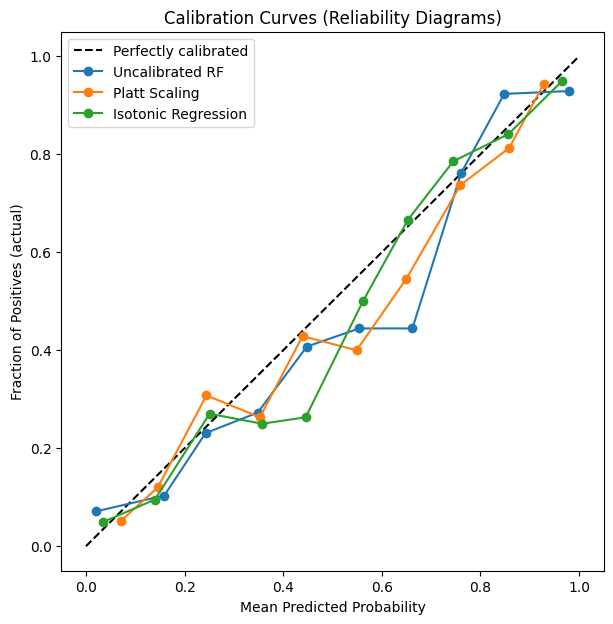

--> The uncalibrated Random Forest's curve often deviates from the diagonal (typically
    overconfident -- predicts probabilities too close to 0 or 1). Calibration methods pull
    the curve closer to the ideal diagonal, giving more trustworthy probability estimates.


In [7]:
# Plot calibration curves (reliability diagrams) for all three
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')

for probs, label in [(probs_uncalibrated, 'Uncalibrated RF'),
                       (probs_platt, 'Platt Scaling'),
                       (probs_isotonic, 'Isotonic Regression')]:
    fraction_pos, mean_pred = calibration_curve(y_test_c, probs, n_bins=10)
    plt.plot(mean_pred, fraction_pos, marker='o', label=label)

plt.xlabel("Mean Predicted Probability"); plt.ylabel("Fraction of Positives (actual)")
plt.title("Calibration Curves (Reliability Diagrams)")
plt.legend()
plt.show()

print("--> The uncalibrated Random Forest's curve often deviates from the diagonal (typically")
print("    overconfident -- predicts probabilities too close to 0 or 1). Calibration methods pull")
print("    the curve closer to the ideal diagonal, giving more trustworthy probability estimates.")


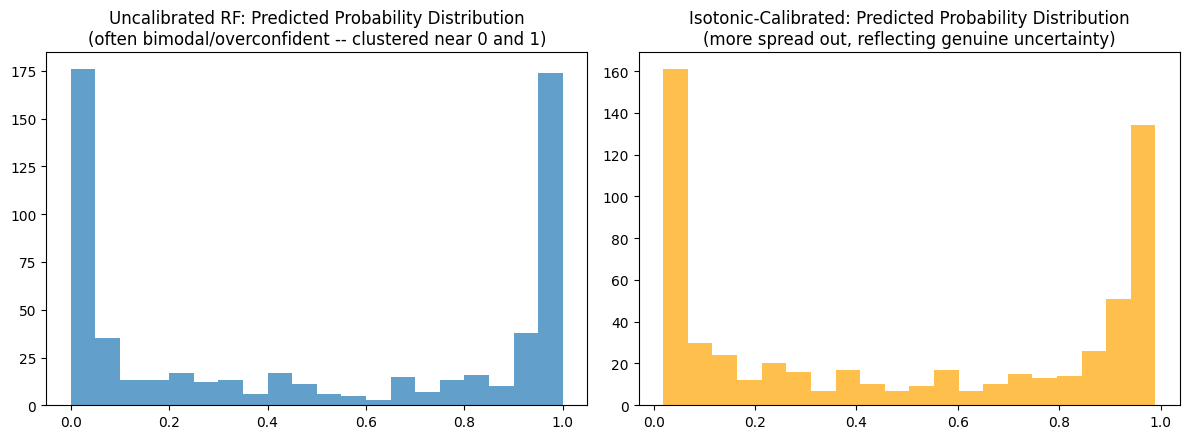

In [8]:
# Show the distribution of predicted probabilities before/after calibration -- a classic overconfidence symptom
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(probs_uncalibrated, bins=20, alpha=0.7)
axes[0].set_title("Uncalibrated RF: Predicted Probability Distribution\n(often bimodal/overconfident -- clustered near 0 and 1)")
axes[1].hist(probs_isotonic, bins=20, alpha=0.7, color='orange')
axes[1].set_title("Isotonic-Calibrated: Predicted Probability Distribution\n(more spread out, reflecting genuine uncertainty)")
plt.tight_layout()
plt.show()


## 6. Coding Practice — Detect Anomalies in a Dataset and Visualize (Comparison)


In [9]:
# Build a slightly more realistic synthetic dataset: normal transaction-like clusters + injected anomalies
np.random.seed(5)
cluster1 = np.random.normal([2, 2], 0.6, (150, 2))
cluster2 = np.random.normal([6, 6], 0.8, (150, 2))
scattered_anomalies = np.random.uniform(-2, 10, (20, 2))

X_anomaly_data = np.vstack([cluster1, cluster2, scattered_anomalies])
true_anomaly_labels = np.array([0]*300 + [1]*20)  # ground truth, held out from all 3 methods' training

scaler_anom = StandardScaler()
X_anomaly_scaled = scaler_anom.fit_transform(X_anomaly_data)

print(f"Dataset: {len(X_anomaly_data)} points, {true_anomaly_labels.sum()} true anomalies ({true_anomaly_labels.mean():.1%})")


Dataset: 320 points, 20 true anomalies (6.2%)


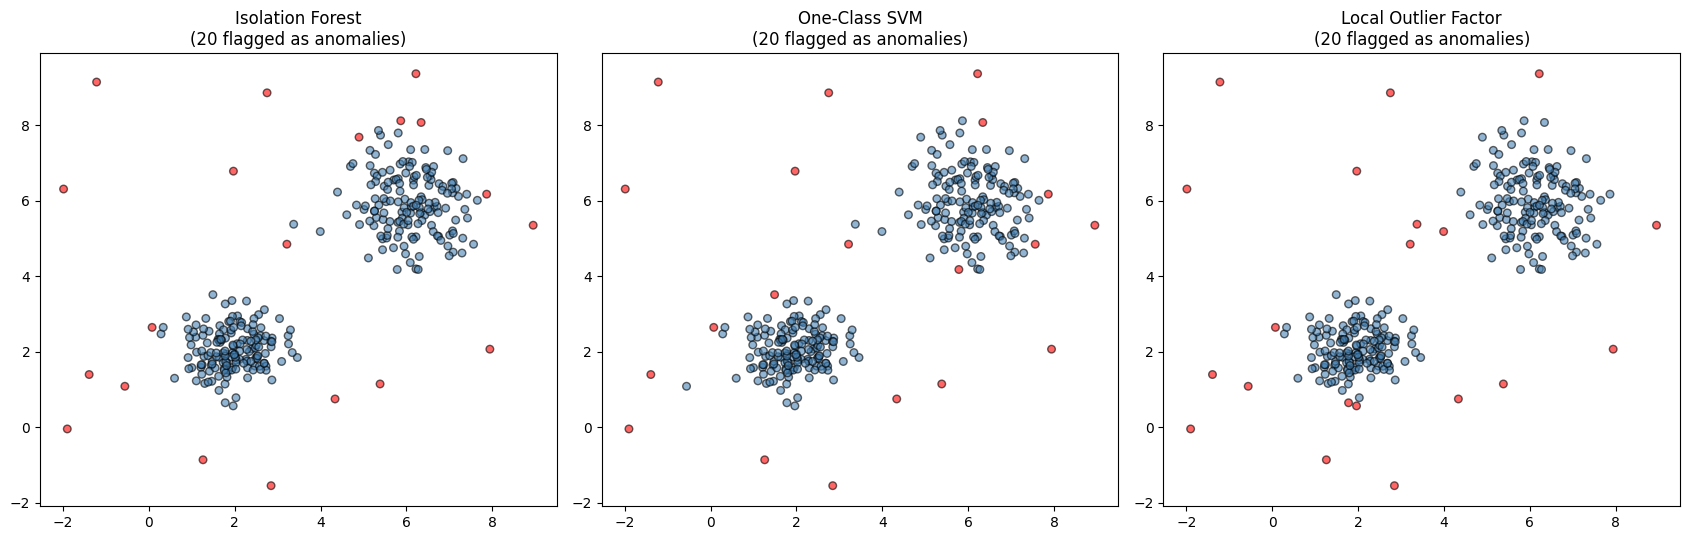

In [10]:
# Run all three anomaly detectors with a matched contamination/nu rate
contamination_rate = 0.06

iso_final = IsolationForest(contamination=contamination_rate, random_state=42)
iso_final_preds = iso_final.fit_predict(X_anomaly_scaled)

svm_final = OneClassSVM(kernel='rbf', gamma='scale', nu=contamination_rate)
svm_final_preds = svm_final.fit_predict(X_anomaly_scaled)

lof_final = LocalOutlierFactor(n_neighbors=20, contamination=contamination_rate)
lof_final_preds = lof_final.fit_predict(X_anomaly_scaled)

# Visualize all three side by side
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, preds, title in zip(axes, [iso_final_preds, svm_final_preds, lof_final_preds],
                              ['Isolation Forest', 'One-Class SVM', 'Local Outlier Factor']):
    colors = np.where(preds == -1, 'red', 'steelblue')
    ax.scatter(X_anomaly_data[:, 0], X_anomaly_data[:, 1], c=colors, alpha=0.6, edgecolor='k', s=30)
    n_flagged = (preds == -1).sum()
    ax.set_title(f"{title}\n({n_flagged} flagged as anomalies)")

plt.tight_layout()
plt.show()


                  Precision  Recall  F1-score  Num Flagged
Method                                                    
Isolation Forest        0.8     0.8       0.8           20
One-Class SVM           0.8     0.8       0.8           20
LOF                     0.8     0.8       0.8           20


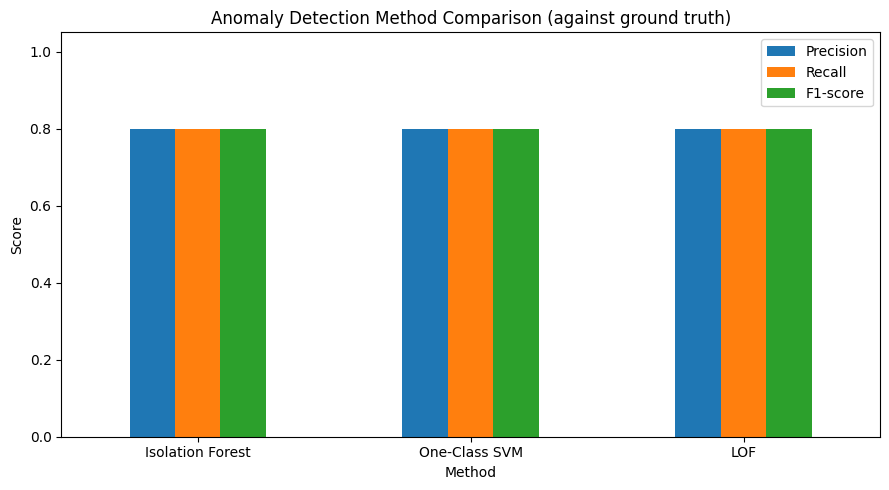

In [11]:
# Evaluate each method against the TRUE anomaly labels (held out, used ONLY for evaluation)
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for name, preds in [('Isolation Forest', iso_final_preds), ('One-Class SVM', svm_final_preds), ('LOF', lof_final_preds)]:
    pred_binary = (preds == -1).astype(int)  # convert -1/1 to 1/0 (1 = anomaly)
    results.append({
        'Method': name,
        'Precision': precision_score(true_anomaly_labels, pred_binary, zero_division=0),
        'Recall': recall_score(true_anomaly_labels, pred_binary, zero_division=0),
        'F1-score': f1_score(true_anomaly_labels, pred_binary, zero_division=0),
        'Num Flagged': pred_binary.sum()
    })

results_df = pd.DataFrame(results).set_index('Method')
print(results_df.round(4))

results_df[['Precision', 'Recall', 'F1-score']].plot(kind='bar', figsize=(9, 5), ylim=(0, 1.05))
plt.title("Anomaly Detection Method Comparison (against ground truth)")
plt.ylabel("Score"); plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Anomaly Detection Comparison + Calibration Notes (Daily Output)

### Anomaly Detection Method Comparison

| Method | Approach | Strengths | Weaknesses | Best for |
|---|---|---|---|---|
| **Isolation Forest** | Randomly isolates points via tree splits; shorter path = more anomalous | Fast, scalable, handles high dimensions well | Can struggle with very local anomalies in mixed-density data | Large datasets, general-purpose first choice |
| **One-Class SVM** | Learns a boundary enclosing "normal" data (kernelized) | Captures complex non-linear normal regions | Sensitive to `nu`/`gamma` choice, slower on large datasets | Smaller datasets with complex normal-region shapes |
| **LOF** | Compares local density of a point to its neighbors | Great for varying-density clusters, catches local anomalies | Slower (needs neighbor computation per point), less scalable | Datasets with multiple clusters of differing density |

### Calibration Notes

- **Always check calibration when downstream decisions depend on probability VALUES**, not just rankings (e.g., risk scoring, cost-sensitive thresholding from Day 15, ensembling multiple models' probabilities).
- **Tree ensembles (Random Forest, Gradient Boosting) and SVMs are commonly overconfident** — their raw probabilities often cluster near 0/1 even when genuine uncertainty exists.
- **Platt Scaling (sigmoid)**: simpler, needs less data, assumes a sigmoid-shaped miscalibration pattern.
- **Isotonic Regression**: more flexible, can fix more complex miscalibration patterns, but needs more data to avoid overfitting the calibration mapping itself.
- **Brier Score** is the go-to single-number summary of calibration + accuracy combined — lower is always better.
- Calibration is done via **cross-validation internally** (`CalibratedClassifierCV`) to avoid overfitting the calibration mapping to the same data the base model was trained on (yet another leakage-avoidance pattern, tying back to Day 10/14).


## ML Connection Recap

| Concept | Connects to |
|---|---|
| Isolation Forest | Day 7's Random Forest/tree-splitting mechanics, applied to isolation instead of classification |
| One-Class SVM | Day 8's SVM kernel trick and margin concepts |
| LOF | Day 6's KNN, Day 11's density-based DBSCAN |
| Semi-supervised pseudo-labeling | Day 4's supervised/unsupervised learning spectrum |
| Calibration | Day 6's log loss (Brier score is a close cousin), Day 15's threshold tuning (meaningless without calibrated probabilities) |


## 8. Interview Questions — Practice Aloud (Close Your Notes!)

1. **How does Isolation Forest detect anomalies, conceptually?**
   *Hint: anomalies are isolated faster (shorter average path length) via random tree splits, since they differ from the bulk of normal data.*

2. **What's the key difference between Isolation Forest/One-Class SVM and LOF?**
   *Hint: Isolation Forest and One-Class SVM learn a GLOBAL notion of "normal"; LOF compares LOCAL density, better suited to datasets with clusters of varying density.*

3. **What is pseudo-labeling, and what's its main risk?**
   *Hint: use a model trained on labeled data to label unlabeled data, add confident predictions back to training; risk is confirmation bias/error amplification if initial confident predictions are wrong.*

4. **What does it mean for a model to be "well-calibrated," and why does it matter?**
   *Hint: predicted probabilities match real-world frequencies; matters for risk scoring, cost-sensitive decisions, and combining model outputs meaningfully.*

5. **Compare Platt Scaling and Isotonic Regression for calibration.**
   *Hint: Platt scaling fits a simple sigmoid (less data needed, less flexible); isotonic regression is a flexible monotonic step function (more data needed, can overfit on small datasets).*

6. **Why are tree ensembles and SVMs often poorly calibrated despite good discrimination ability?**
   *Hint: their training objectives (e.g., voting/averaging, margin maximization) don't directly optimize for probability calibration — they optimize for correct ranking/classification, not calibrated confidence.*

7. **(Bonus) Why must calibration be performed using cross-validation rather than on the same data the base model was trained on?**
   *Hint: fitting the calibration mapping on the training set's own (overconfident, memorized) predictions would just reinforce the same miscalibration rather than correct it — needs held-out-style validation, similar to Day 10/14's leakage principles.*


## 9. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain Isolation Forest's "path length" intuition for detecting anomalies.
- [ ] Explain One-Class SVM's approach to learning a "normal" boundary.
- [ ] Explain LOF's local density comparison and when it outperforms global methods.
- [ ] Explain semi-supervised learning and pseudo-labeling, including its main risk.
- [ ] Define calibration, and explain the Brier score and calibration curves.
- [ ] Compare Platt Scaling and Isotonic Regression for probability calibration.
- [ ] Run and compare Isolation Forest, One-Class SVM, and LOF on a dataset with ground-truth anomalies.

### 📌 Daily Output (per the planner)
An **anomaly detection comparison + calibration notes** document (Section 7) — Isolation Forest, One-Class SVM, and LOF compared on approach, strengths, weaknesses, and best-use scenarios, evaluated against ground-truth anomalies (Section 6), plus practical calibration notes (Platt vs. Isotonic, Brier score, when calibration matters) informed by the reliability-diagram experiment in Section 5.

Close this notebook and re-explain, from memory, why a Random Forest's raw predicted probabilities are often overconfident and how you'd fix that — that's the real test of Day 16 mastery.
